In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from nested_pandas import read_parquet

In [3]:
nf = read_parquet('test.parquet')
print(f'{len(nf)} objects')
nf.head()

3 objects


ra       dec  \
rootid                                                       
525fc66d-a94d-4278-a661-6d5809bcfbc5  149.135272  1.570663   
9a7690a2-f9d2-47d3-b738-021919fa660d  151.544502  2.716802   
eab7b491-8882-49f2-826b-4a7ce2ded28e  151.150967  2.346289   

                                               diaobjectid  \
rootid                                                       
525fc66d-a94d-4278-a661-6d5809bcfbc5  [170336356281614359]   
9a7690a2-f9d2-47d3-b738-021919fa660d  [170336356503388205]   
eab7b491-8882-49f2-826b-4a7ce2ded28e  [170336356481892438]   

                                                                             lightcurve  
rootid                                                                                   
525fc66d-a94d-4278-a661-6d5809bcfbc5  [{diaforcedsourceid: NaN, diasourceid: 1.70336...  
9a7690a2-f9d2-47d3-b738-021919fa660d  [{diaforcedsourceid: NaN, diasourceid: 1.70336...  
eab7b491-8882-49f2-826b-4a7ce2ded28e  [{diaforcedsourceid: NaN, diasourceid: 1.70336...

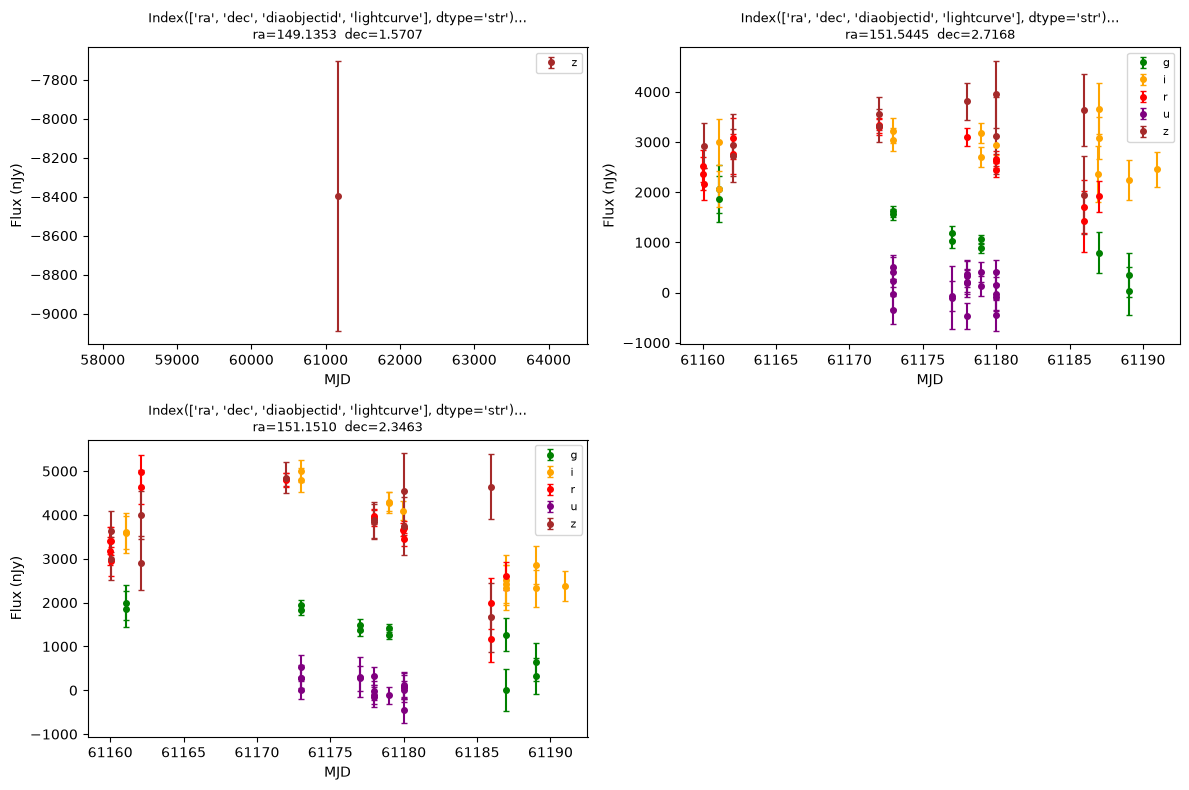

In [5]:
BAND_COLORS = {'u': 'purple', 'g': 'green', 'r': 'red', 'i': 'orange', 'z': 'brown', 'Y': 'black'}

n = len(nf)
ncols = 2
nrows = (n + 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows), squeeze=False)

for ax, (_, row) in zip(axes.flat, nf.iterrows()):
    lc = pd.DataFrame(row['lightcurve'])
    for band, grp in lc.groupby('band'):
        color = BAND_COLORS.get(band, 'gray')
        ax.errorbar(grp['mjd'], grp['flux'], yerr=grp['fluxerr'],
                    fmt='o', color=color, label=band, markersize=4, capsize=2)
    rootid = row.index
    ax.set_title(f'{rootid[:8]}…\nra={row["ra"]:.4f}  dec={row["dec"]:.4f}', fontsize=9)
    ax.set_xlabel('MJD')
    ax.set_ylabel('Flux (nJy)')
    ax.legend(fontsize=8)

for ax in axes.flat[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()